# Titanic - Machine Learning from Disaster

Names: Itamar Hadad 

Kaggle Profile: https://www.kaggle.com/itamarhadadml

**Introduction**

The Titanic, a ship famously believed to be unsinkable, met a tragic fate on April 15, 1912, during its first journey. 
Striking an iceberg, the disaster claimed 1502 lives out of the 2224 passengers and crew aboard. 

This historic event forms the basis of a compelling machine learning challenge: predicting which passengers were more likely to survive.
This competition challenges us to use machine learning to build a model capable of answering the key question: "What factors increased the likelihood of survival during the Titanic disaster?" By exploring attributes such as passenger age, gender, socio-economic status, and more, the goal is to uncover patterns and insights that shed light on survival probabilities.

Analyzing this data not only helps in developing predictive skills but also provides a deeper understanding of the social and demographic factors that played a role in survival. Together, we delve into the Titanic dataset to reveal the key variables that determined who survived and who didn’t during one of history’s most infamous maritime disasters.

In [49]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    log_loss, confusion_matrix,  make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline 
from sklearn.model_selection import train_test_split , GridSearchCV  # Train/test split function
from IPython.display import display
from sklearn.metrics import roc_curve, auc
import random
# Set a seed for the random number generator
random.seed(42) 

In [50]:
# Function to fill missing values with the mean
def fill_age_with_mean(data):
    data_copy = data.copy()
    mean_value = data_copy['Age'].mean()
    missing_before = data_copy['Age'].isnull().sum()
    data_copy['Age'] = data_copy['Age'].fillna(mean_value)
    print(f"Filled {missing_before} missing 'Age' values with the mean: {mean_value:.2f}")
    return data_copy


# Function to fill missing values with prediction (Linear Regression)
def fill_age_with_prediction(data):
    data_copy = data.copy()

    # Separate rows with and without missing 'Age'
    age_not_null = data_copy[data_copy['Age'].notnull()]
    age_null = data_copy[data_copy['Age'].isnull()]

    # Features to use for prediction
    features = ['Pclass', 'Sex', 'Embarked', 'Fare', 'SibSp', 'Parch']

    # Preprocessing pipeline
    pipeline = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['Fare', 'SibSp', 'Parch']),
            ('cat', OneHotEncoder(drop='first'), ['Pclass', 'Sex', 'Embarked'])
        ],
        remainder='passthrough'
    )

    # Prepare data for training
    X_train = pipeline.fit_transform(age_not_null[features])
    y_train = age_not_null['Age']

    # Train Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prepare data for prediction
    X_predict = pipeline.transform(age_null[features])

    # Predict missing 'Age' values
    predicted_ages = model.predict(X_predict)

    # Clamp predictions to valid range
    min_age = age_not_null['Age'].min()  # Lowest age in the data
    max_age = age_not_null['Age'].max()  # Highest age in the data
    predicted_ages = np.clip(predicted_ages, min_age, max_age)

    # Convert predictions to integers while preserving a realistic range
    predicted_ages = np.round(predicted_ages).astype(int)

    # Ensure no unrealistic values (e.g., ages less than 1 year old)
    predicted_ages[predicted_ages < 1] = 1

    # Fill the missing 'Age' values
    data_copy.loc[data_copy['Age'].isnull(), 'Age'] = predicted_ages

    print(f"Filled {len(predicted_ages)} missing 'Age' values using Linear Regression.")
    print(f"Age range used: {min_age} to {max_age}")
    return data_copy


# Function to let the user choose the imputation method
def choose_age_imputation_method(data):
    print("Choose the method for imputing missing 'Age' values:")
    print("Type 'mean' for Mean Imputation")
    print("Type 'prediction' for Prediction-Based Imputation (Linear Regression)")
    
    # Loop until a valid choice is provided
    while True:
        choice = input("Enter your choice (mean/prediction): ").strip().lower()
        if choice == "mean":
            print("You chose Mean Imputation.")
            return fill_age_with_mean(data), "Mean Imputation"
        elif choice == "prediction":
            print("You chose Prediction-Based Imputation.")
            return fill_age_with_prediction(data), "Prediction-Based Imputation"
        else:
            print("Invalid choice. Please type 'mean' or 'prediction'.")

# Visualize Age Distribution Before and After Filling
def plot_age_distributions(data, filled_data, method_used):
    plt.figure(figsize=(12, 6))
    
    # Original missing data (before imputation)
    sns.kdeplot(data=data['Age'], color='orange', label='Before Imputation', fill=True)

    # Imputed values (after imputation)
    sns.kdeplot(data=filled_data['Age'], color='blue', label=f'{method_used} Filled Values', fill=True)

    plt.title(f"Comparison of Age Distributions Before and After Filling ({method_used})")
    plt.xlabel("Age")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


def preprocess_cabin(df):
    # Copy DataFrame to avoid modifying the original
    df_copy = df.copy()
    
    # Extract the first letter of the 'Cabin' column and create the 'Deck' column
    df_copy["Deck"] = df_copy["Cabin"].str.slice(0, 1).fillna("N")  # Fill missing cabins with "N"
    
    return df_copy

# Ordinal encode the 'AgeBin' column
def ordinalencoder(df, labels, drop_col=False):
    """
    This function will ordinal encode a list of specified columns using OrdinalEncoder.
    
    Args:
        df (pandas.DataFrame): The DataFrame to be processed.
        labels (list of str): List of the column labels to encode.
        drop_col (bool, optional): Boolean to decide if the chosen columns should be dropped. Defaults to False.
        
    Returns:
        pandas.DataFrame: A DataFrame with the specified columns ordinal encoded.
    """
    # Ensure labels is a list, even if only one label is provided
    if isinstance(labels, str):
        labels = [labels]
    
    # Initialize the OrdinalEncoder
    encoder = OrdinalEncoder(handle_unknown='error')
    
    # Process each specified label
    for label in labels:
        # Fit and transform the specified column
        encoded_data = encoder.fit_transform(df[[label]])
        
        # Create a new column name for the encoded data
        new_col = f"{label}_Encoded"
        
        # Insert the encoded data into the DataFrame
        df[new_col] = encoded_data
        
        # Drop the original column from df if drop_col is True
        if drop_col:
            df = df.drop(label, axis=1)
    
    return df

def split_data(dataset, target):
    """
    Splits the dataset into training and validation sets.
    
    Args:
        dataset (pd.DataFrame): The dataset to be split.
        target (str): The target column name for prediction.
    
    Returns:
        x_train, x_val, t_train, t_val: Training and validation features and targets.
    """
    # Extract target variable
    t = dataset[[target]]
    
    # Drop target from features
    x = dataset.drop(columns=target)
    
    # Split into training and validation sets
    x_train, x_val, t_train, t_val = train_test_split(
        x, t, test_size=0.12, random_state=42
    )
    
    # Reset indices for consistency
    x_train = x_train.reset_index(drop=True)
    x_val = x_val.reset_index(drop=True)
    t_train = t_train.reset_index(drop=True)
    t_val = t_val.reset_index(drop=True)
    
    return x_train, x_val, t_train, t_val

# Define KPI calculation function
def model_kpi(y_true, y_pred):
    """
    Calculates evaluation metrics and confusion matrix for model performance.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        metrics_df (pd.DataFrame): DataFrame containing evaluation metrics.
        confusion_mtx (np.array): Confusion matrix.
    """
    confusion_mtx = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = confusion_mtx.ravel()

    # Compute metrics
    metrics_dict = {
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Specificity': tn / (tn + fp),
        'FPR': fp / (fp + tn),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

    # Convert metrics to DataFrame
    metrics_df = pd.DataFrame(metrics_dict, index=[0])
    return metrics_df, confusion_mtx

# Define function to plot results
def plot_results(grid_search):
    results = grid_search.cv_results_
    
    # Extract scores and convert log loss to positive values for plotting
    mean_train_accuracy = results['mean_train_accuracy']
    mean_test_accuracy = results['mean_test_accuracy']
    mean_train_log_loss = -results['mean_train_neg_log_loss']
    mean_test_log_loss = -results['mean_test_neg_log_loss']

    # Simplifying parameter names for display in the plot
    params = [str(x) for x in results['params']]
    simplified_params = ['\n'.join([key.split('__')[-1] + '=' + str(value)
                                    for key, value in eval(param).items()]) for param in params]

    # Setup the figure and subplots
    fig, ax = plt.subplots(2, 1, figsize=(12, 16))

    # Plotting Accuracy
    ax[0].plot(simplified_params, mean_train_accuracy, label='Train Accuracy', marker='o', color='blue')
    ax[0].plot(simplified_params, mean_test_accuracy, label='Validation Accuracy', marker='o', color='red')
    ax[0].set_title('Training vs Validation Accuracy')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].set_xticks(np.arange(len(simplified_params)))  # Set x-ticks locations
    ax[0].set_xticklabels(simplified_params, rotation=90)  # Set x-ticks labels
    
    # Annotating the best accuracy value
    best_acc_index = np.argmax(mean_test_accuracy)
    best_acc = mean_test_accuracy[best_acc_index]
    ax[0].annotate(f'Best Validation Accuracy:\n{best_acc:.4f}', 
                   xy=(best_acc_index, best_acc), xycoords='data',
                   xytext=(50, 30), textcoords='offset points',
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black'))
    
    # Plotting Log Loss
    ax[1].plot(simplified_params, mean_train_log_loss, label='Train Log Loss', marker='o', color='blue')
    ax[1].plot(simplified_params, mean_test_log_loss, label='Validation Log Loss', marker='o', color='red')
    ax[1].set_title('Training vs Validation Log Loss')
    ax[1].set_xlabel('Parameters')
    ax[1].set_ylabel('Log Loss')
    ax[1].legend()
    ax[1].set_xticks(np.arange(len(simplified_params)))  # Set x-ticks locations
    ax[1].set_xticklabels(simplified_params, rotation=90)  # Set x-ticks labels

    # Annotating the best log loss value
    best_loss_index = np.argmin(mean_test_log_loss)
    best_loss = mean_test_log_loss[best_loss_index]
    ax[1].annotate(f'Best Validation Log Loss:\n{best_loss:.4f}', 
                   xy=(best_loss_index, best_loss), xycoords='data',
                   xytext=(50, -40), textcoords='offset points',
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-.2', color='black'))

    plt.tight_layout()
    plt.show()

def confusion_table(confusion_mtx):
    """Renders a nice confusion table with labels"""
    confusion_df = pd.DataFrame({'<div style="text-align: center;">Predicted<br>0</div>': np.append(confusion_mtx[:, 0], confusion_mtx.sum(axis=0)[0]),
                                 '<div style="text-align: center;">Predicted<br>1</div>': np.append(confusion_mtx[:, 1], confusion_mtx.sum(axis=0)[1]),
                                 'Total': np.append(confusion_mtx.sum(axis=1), ''),
                                 '': ['<div style="text-align: center;">Actual<br>0</div>', '<div style="text-align: center;">Actual<br>1</div>', 'Total']}).set_index('')
    confusion_df = confusion_df.style.set_table_styles([{
    'selector': 'th.row_heading, th.blank',
    'props': [('font-weight', 'bold')] # Style Index Names As Bold
}], overwrite=False)
    return confusion_df

# Function to display TN, FP, FN, TP counts from confusion matrix
def display_confusion_metrics(confusion_mtx, dataset_name):
    """
    Display the TN, FP, FN, and TP counts from the confusion matrix.

    Args:
        confusion_mtx (numpy.ndarray): Confusion matrix.
        dataset_name (str): Name of the dataset (e.g., "Train" or "Validation").
    """
    tn, fp, fn, tp = confusion_mtx.ravel()
    print(f"{dataset_name}: TN {tn}, FP {fp}, FN {fn}, TP {tp}")

**Load Data**

In [51]:
# --- Load and Explore Data ---
train_path = "/Users/itamarhadad/Desktop/study/MachineLearning/newtask2/train.csv"
test_path = "/Users/itamarhadad/Desktop/study/MachineLearning/newtask2/test.csv"
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

In [52]:

train_data.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [53]:

train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [54]:

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [55]:
#%%

train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [56]:

test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [57]:

test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [58]:

train_data["PassengerId"]

0        1
1        2
2        3
3        4
4        5
      ... 
886    887
887    888
888    889
889    890
890    891
Name: PassengerId, Length: 891, dtype: int64

In [59]:
#%%

test_data["PassengerId"]

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

In [60]:
#%%

# Save PassengerId for train and test data
train_ids = train_data['PassengerId']
test_ids = test_data['PassengerId']

First, we load the Titanic dataset to examine its structure and understand the data it contains.

The dataset is divided into two parts:

    - Training set: Contains passenger details along with their survival status (whether they survived or not).

    - Test set: Includes passenger details but lacks survival information, which is to be predicted.

As shown in the figure below, both the training and test datasets have missing values that will need to be handled before proceeding with further analysis.


By merging the training and test sets, we create a unified dataset that facilitates consistent data preprocessing and analysis. 

This comprehensive dataset includes details such as passenger names, ages, genders, ticket classes, fares, and survival status.


In [61]:
#%%

# Combine train and test datasets
test_data['Survived'] = np.nan
combined_data = pd.concat([train_data, test_data], ignore_index=True)

# Save 'Survived' label for training data
train_survived = combined_data.loc[~combined_data['Survived'].isna(), 'Survived'].astype(int)  # For training data
print("\nTraining Labels (Survived):")
print(train_survived.value_counts())

# Drop 'Survived' permanently from combined_data
combined_data = combined_data.drop(columns=['Survived'])


Training Labels (Survived):
Survived
0    549
1    342
Name: count, dtype: int64


In [62]:
#%%

combined_data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [63]:
#%%

# Display dataset information
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [64]:
#%%

# Visualize missing values numerically
missing_values = combined_data.isnull().sum()
print("\nMissing Values in Combined Data:")
print(missing_values)


Missing Values in Combined Data:
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


Upon examining the Titanic dataset, we observed missing values in several important features. 

Specifically, there were 263 missing values in the 'Age' feature, 1 missing value in 'Fare', 1014 missing values in 'Cabin', and 2 missing values in 'Embarked'.

To handle the missing values in the 'Fare' and 'Embarked' features, we used the mode imputation method. 

This approach involved replacing the missing values with the most frequently occurring fare and port of embarkation within the dataset.


In [65]:
# Impute missing 'Embarked' values with the mode
combined_data['Embarked'] = combined_data['Embarked'].fillna(combined_data['Embarked'].mode()[0])

# Impute missing 'Fare' values with the mode
combined_data['Fare'] = combined_data['Fare'].fillna(combined_data['Fare'].mode()[0])

In the Titanic dataset, missing values in the 'Age' column are handled through two imputation methods, allowing users to choose the most suitable approach for their analysis:

*Mean Imputation:*

This method calculates the mean of the existing 'Age' values and fills the missing entries with this mean.
While simple and computationally inexpensive, it does not consider the relationships between 'Age' and other features, potentially introducing bias.



*Prediction-Based Imputation (Linear Regression):*

This advanced method uses a linear regression model trained on rows with non-missing 'Age' values.
Features such as 'Pclass', 'Sex', 'Embarked', 'Fare', 'SibSp', and 'Parch' are used to predict the missing 'Age' values.
The predicted values are clamped to the range of existing ages to ensure consistency and realistic results.


The choose_age_imputation_method function prompts the user to select either Mean Imputation or Prediction-Based Imputation.
If the user provides an invalid input, the script will continue to prompt them until a valid choice is made. The script does not proceed automatically without a valid input.


Missing Values After Imputation:
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64
Choose the method for imputing missing 'Age' values:
Type 'mean' for Mean Imputation
Type 'prediction' for Prediction-Based Imputation (Linear Regression)
You chose Mean Imputation.
Filled 263 missing 'Age' values with the mean: 29.88


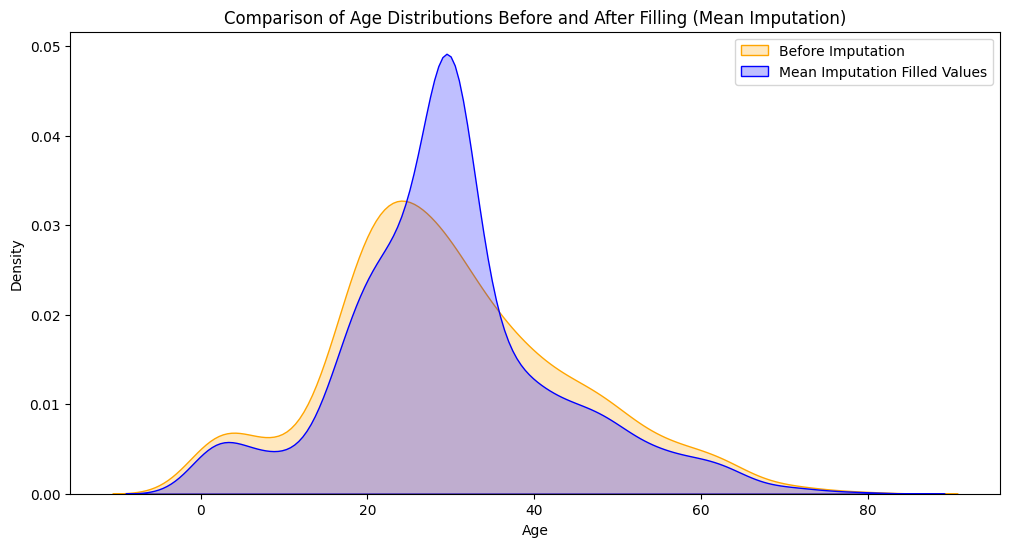

In [66]:
# Display missing values after imputation
print("\nMissing Values After Imputation:")
print(combined_data.isnull().sum())


# Save a copy of the dataset before filling age values
original_combined_data = combined_data.copy()

# Allow user to choose imputation method
combined_data, method_used = choose_age_imputation_method(combined_data)

# Visualize Age Distribution Before and After Filling
plot_age_distributions(original_combined_data, combined_data, method_used)

In [67]:

print("Missing 'Age' values in combined_data AFTER imputation:")
print(combined_data['Age'].isnull().sum())

Missing 'Age' values in combined_data AFTER imputation:
0


**Feature Engineering**

During feature engineering, our primary goal was to refine the dataset to enhance the predictive capabilities of our model while maintaining robustness against outliers and variability.

 
•	Title Extracion from Names: 

Upon examining the 'Name' feature, we identified a variety of titles associated with passengers. 

These titles provided valuable insights into passengers' social status and demographic profiles. 

However, the dataset also included rare or unconventional titles that could potentially introduce noise and reduce the model's ability to generalize effectively. 

To address this, we grouped rare titles into broader, more commonly used categories. This step ensured that the feature captured meaningful distinctions while reducing the risk of overfitting caused by infrequent titles.

In [68]:

# Extract titles from the 'Name' column in combined_data
combined_data['Title'] = combined_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
combined_data.Title.value_counts()

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Mlle          2
Major         2
Ms            2
Lady          1
Sir           1
Mme           1
Don           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

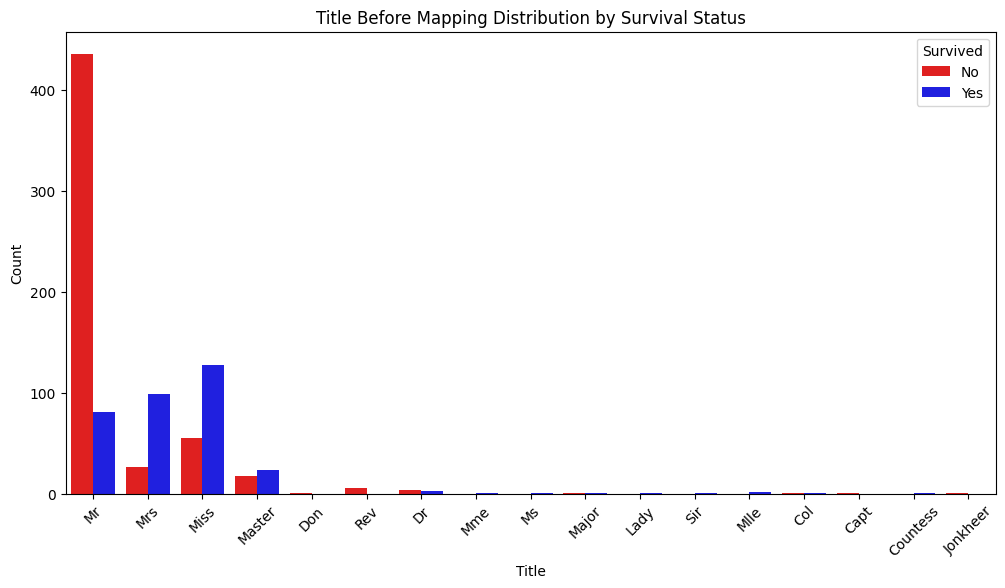

In [69]:

# Visualize the distribution of titles before mapping (only rows corresponding to train_data)
plt.figure(figsize=(12, 6))
sns.countplot(
    data=combined_data.loc[: len(train_data) - 1],  # Use only rows corresponding to train_data
    x='Title',
    hue=train_survived,
    palette=['red', 'blue']
)
plt.title("Title Before Mapping Distribution by Survival Status")
plt.xlabel("Title")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.xticks(rotation=45)
plt.show()


We extracted titles from passenger names to capture indicators of social status, which may correlate with survival rates. This process enriched our dataset with meaningful socio-demographic information.

To manage the variability in titles, we grouped them into a smaller set of standardized categories. By doing so, we ensured the model could leverage this feature effectively without being overly influenced by rare or outlier titles. This approach enhanced the dataset's informativeness while reducing noise and potential overfitting.

In [70]:

# Map rare titles to a common category in combined_data
mapping = {'Mlle': 'Miss', 'Major': 'Mr', 'Col': 'Mr', 'Sir': 'Mr',
           'Don': 'Mr', 'Mme': 'Mrs', 'Jonkheer': 'Mr', 'Lady': 'Mrs',
           'Capt': 'Mr', 'Countess': 'Mrs', 'Ms': 'Miss', 'Dona': 'Mrs'}
combined_data['Title'] = combined_data['Title'].replace(mapping)
combined_data['Title'].value_counts()

Title
Mr        767
Miss      264
Mrs       201
Master     61
Rev         8
Dr          8
Name: count, dtype: int64

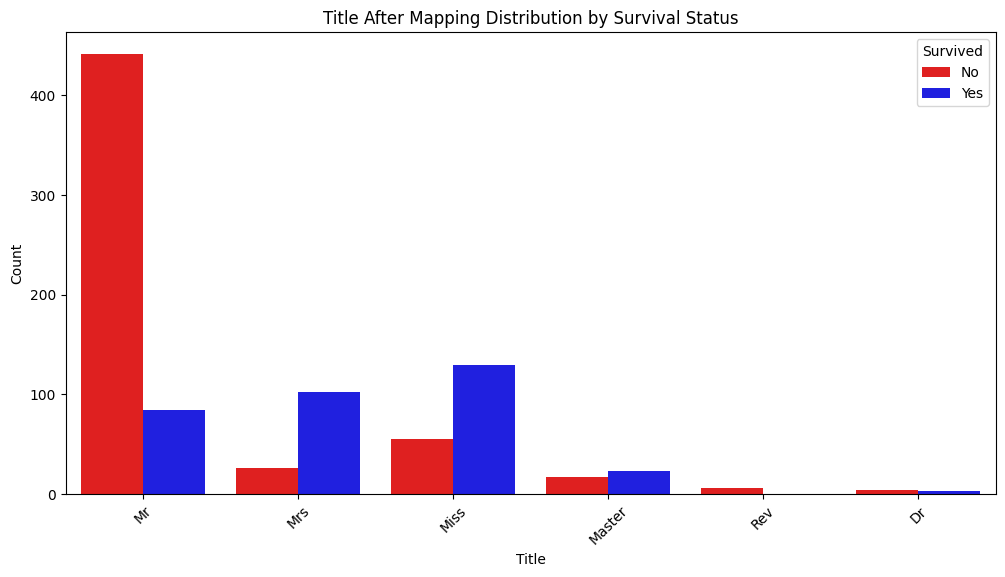

In [71]:

# Visualize the distribution of titles after mapping (only rows corresponding to train_data)
plt.figure(figsize=(12, 6))
sns.countplot(
    data=combined_data.loc[: len(train_data) - 1],  # Use only rows corresponding to train_data
    x='Title',
    hue=train_survived,
    palette=['red', 'blue']
)
plt.title("Title After Mapping Distribution by Survival Status")
plt.xlabel("Title")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.xticks(rotation=45)
plt.show()

In [72]:
# Drop unnecessary columns
combined_data = combined_data.drop(columns=['Name', 'Ticket'])

•	Family Size: 

Understanding the dynamics of family size aboard the Titanic was crucial, as it could provide valuable insights into survival patterns. To capture this, we created a new feature, FamilySize, by aggregating existing variables such as SibSp (number of siblings/spouses aboard) and Parch (number of parents/children aboard). This feature condensed multiple variables into a single, more informative measure, helping the model interpret family-related survival influences more effectively.

Additionally, we introduced the IsAlone feature, a binary variable indicating whether a passenger traveled alone or with family. This refinement provided a clear distinction between solo travelers and those with family, enabling the model to identify potential differences in survival probabilities more precisely. 

These engineered features enriched our dataset, making it more descriptive and impactful for the predictive model.

In [73]:
# Add FamilySize and IsAlone features
combined_data['FamilySize'] = combined_data['SibSp'] + combined_data['Parch'] + 1
combined_data['IsAlone'] = 0
combined_data.loc[combined_data['FamilySize'] == 1, 'IsAlone'] = 1

# Check the first few rows to confirm the new features
print(combined_data[['FamilySize', 'IsAlone']].head())

   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1


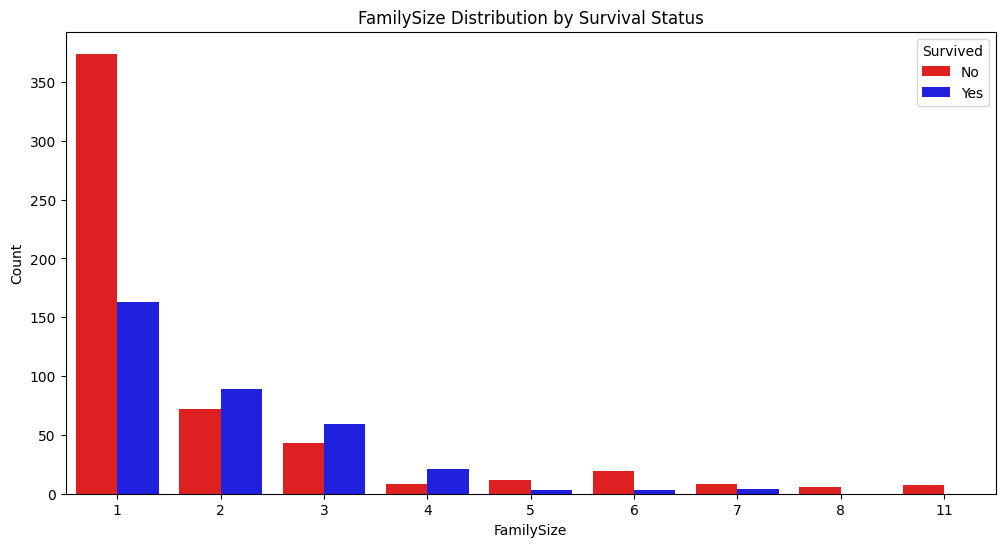

In [74]:
# Visualize FamilySize distribution by Survival Status
plt.figure(figsize=(12, 6))
sns.countplot(
    data=combined_data.loc[: len(train_data) - 1],  # Only rows corresponding to train_data
    x='FamilySize',
    hue=train_survived,
    palette=['red', 'blue']
)
plt.title("FamilySize Distribution by Survival Status")
plt.xlabel("FamilySize")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

The motivation for creating the IsAlone feature stemmed from the hypothesis that passengers traveling alone might have behaved differently or received varying levels of assistance compared to those traveling with family. 

For example, passengers accompanied by family might have prioritized collective survival strategies, shared resources, or received assistance from their relatives during the chaotic evacuation process.

By introducing this feature, we aimed to isolate the distinction between solo travelers and those with family onboard, enhancing our model’s ability to identify subtle patterns in survival rates. This refinement helped uncover nuanced relationships between family status and survival outcomes, improving the model’s overall predictive performance.


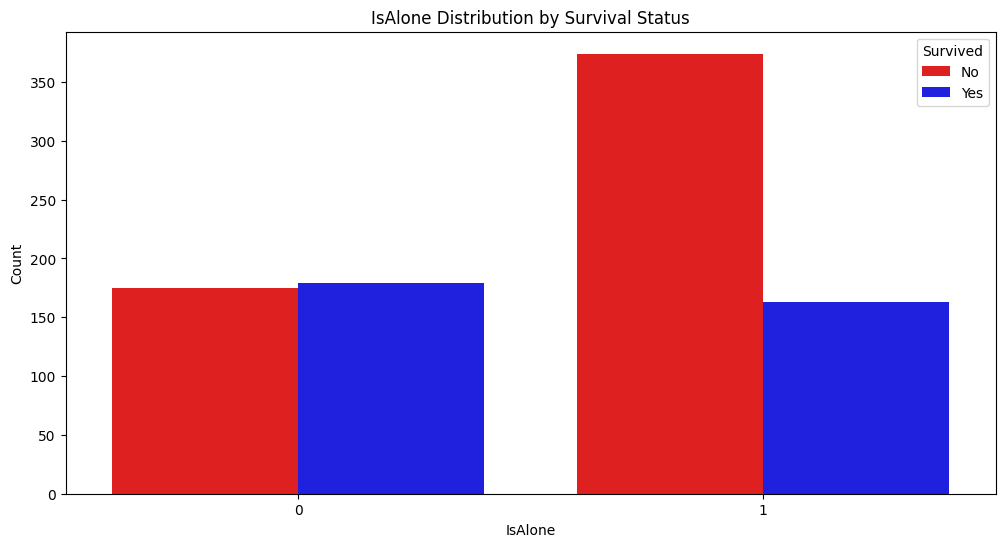

In [75]:
# Visualize IsAlone distribution by Survival Status
plt.figure(figsize=(12, 6))
sns.countplot(
    data=combined_data.loc[: len(train_data) - 1],  # Only rows corresponding to train_data
    x='IsAlone',
    hue=train_survived,
    palette=['red', 'blue']
)
plt.title("IsAlone Distribution by Survival Status")
plt.xlabel("IsAlone")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

•	Cabin Deck Identification:

We identified the potential value of the deck information embedded within the 'Cabin' feature. By extracting this data, we sought to gain deeper insights into passenger demographics and their spatial placement aboard the Titanic. This choice was driven by the assumption that a passenger's deck might reflect their socioeconomic status, proximity to lifeboats, and, consequently, their likelihood of survival.


To extract the deck information from the 'Cabin' feature, we isolated the alphabetic component of each cabin identifier using string slicing. This process generated a new feature, 'Deck,' which indicates the deck level associated with each passenger's cabin.

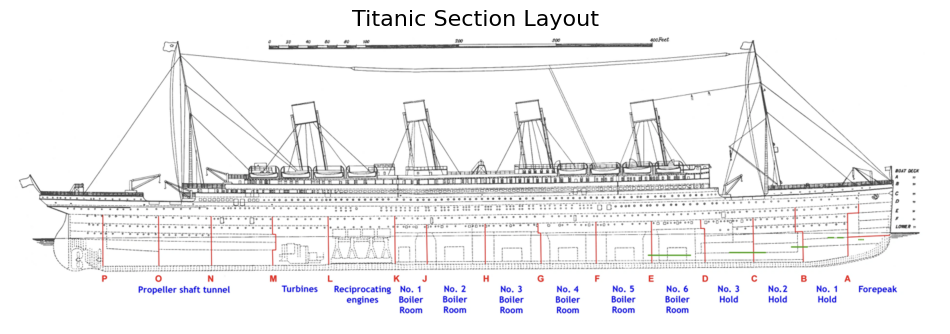

In [76]:
image_path = '/Users/itamarhadad/Desktop/study/MachineLearning/newtask2/titanic full deck.png' 

img = mpimg.imread(image_path)

plt.figure(figsize=(12, 6))  
plt.imshow(img)
plt.axis('off') 
plt.title('Titanic Section Layout', fontsize=16) 
plt.show()

By grouping passengers according to their assigned decks, we aimed to identify potential differences in survival rates among those located in various sections of the ship.

In [77]:

# Preprocess the 'Cabin' column to extract the 'Deck' feature
combined_data = preprocess_cabin(combined_data)

# Drop the original 'Cabin' column as it is no longer needed
combined_data.drop(columns=['Cabin'], inplace=True)

# Check the first few rows to confirm the new 'Deck' feature
print(combined_data[['Deck']].head())

  Deck
0    N
1    C
2    N
3    C
4    N


•	Age and Fare Grouping: 

To enhance the effectiveness of our predictive model, we identified the need to group passengers based on age and fare into meaningful categories. This approach aimed to address the challenges posed by skewed distributions, variability, and outliers, particularly in these continuous variables.

The Fare feature exhibited a wide range of values with a highly skewed distribution. 

To mitigate the influence of outliers and reveal potential patterns, we categorized fares into discrete intervals (or bins). The bins were defined as follows:

•	'Poor': Fares below 5

•	'Low': Fares between 5 and 14.9

•	'Medium': Fares between 14.9 and 34.9

•	'High': Fares between 34.9 and 84.9

•	'VeryHigh': Fares above 84.9


By applying this binning technique, we introduced a structured feature that is easier for the model to interpret and analyze. The resulting categories also help to highlight potential relationships between fare levels and survival likelihood.


To illustrate the impact of this grouping, the following charts compare the Fare distribution before and after grouping:

1.	Before Grouping: The raw Fare distribution reveals a heavily skewed pattern, with a small number of high values significantly influencing the range.

2.	After Grouping: The grouped Fare categories distribute passengers into distinct, interpretable segments, making the analysis more robust and informative.


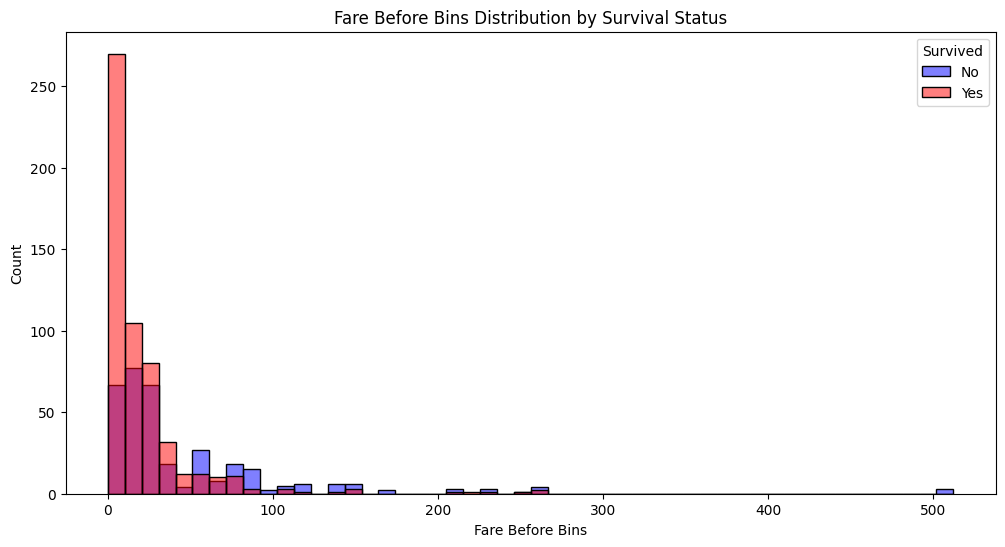

In [78]:

# Visualize Fare distribution before binning
plt.figure(figsize=(12, 6))
sns.histplot(data=combined_data.loc[: len(train_data) - 1], x='Fare', hue=train_survived, kde=False, bins=50, palette=['red', 'blue'])
plt.title("Fare Before Bins Distribution by Survival Status")
plt.xlabel("Fare Before Bins")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

In [79]:
# Bin 'Fare'
combined_data['FareBin'] = pd.cut(combined_data['Fare'], bins=[-0.1, 5, 14.9, 34.9, 84.9, 513],
                                  labels=['Poor', 'Low', 'Medium', 'High', 'VeryHigh'])

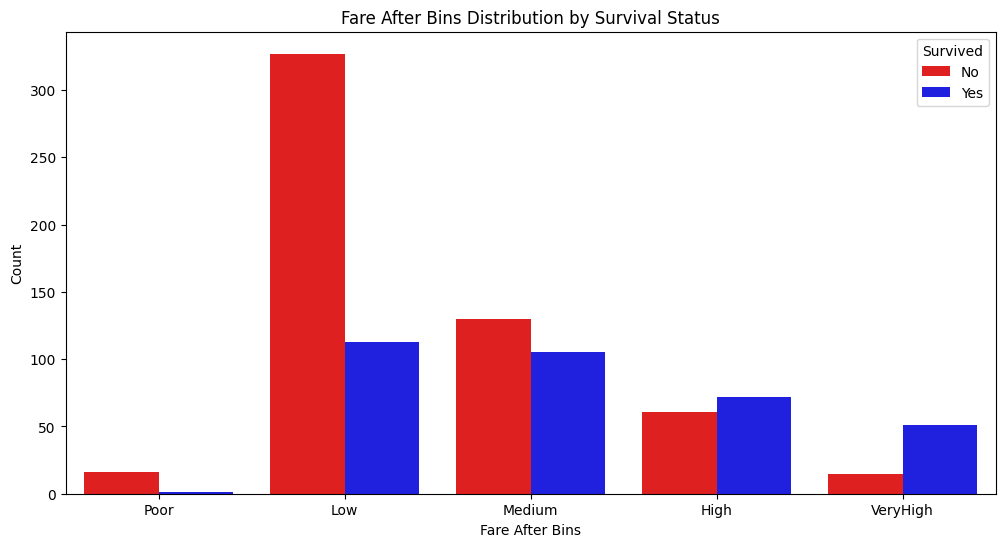

In [80]:
# Visualize Fare distribution after binning
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_data.loc[: len(train_data) - 1], x='FareBin', hue=train_survived, palette=['red', 'blue'])
plt.title("Fare After Bins Distribution by Survival Status")
plt.xlabel("Fare After Bins")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

We visualized the 'Embarked' column as a preparatory step before encoding it alongside the 'FareBin' feature.

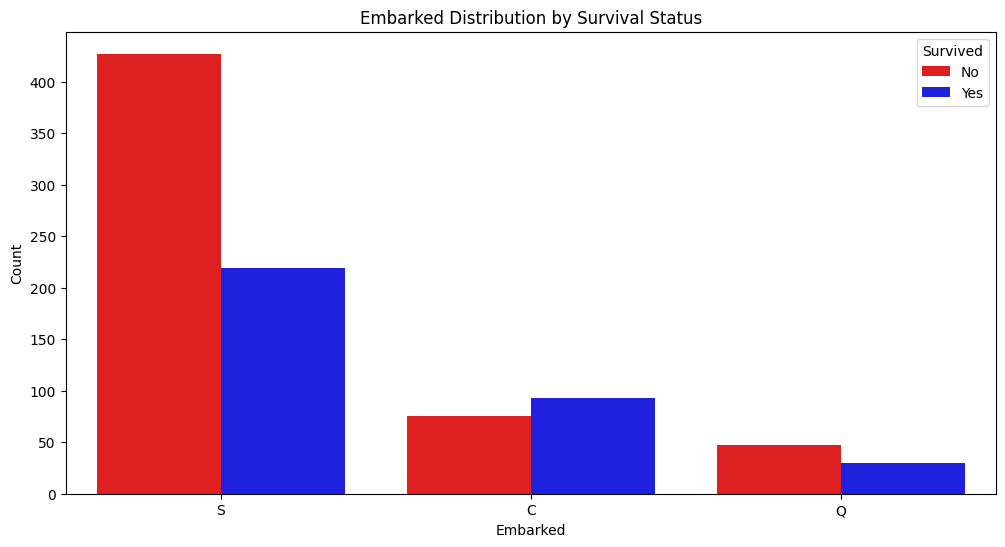

In [81]:
# Visualize Embarked distribution by Survival Status
plt.figure(figsize=(12, 6))
sns.countplot(
    data=combined_data.loc[: len(train_data) - 1],  # Only rows corresponding to train_data
    x='Embarked',
    hue=train_survived,
    palette=['red', 'blue']
)
plt.title("Embarked Distribution by Survival Status")
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

In [82]:
# Apply ordinal encoding to specific categorical columns and drop the original columns
combined_data = ordinalencoder(combined_data, labels=['Title', 'FareBin', 'Sex', 'Deck', 'Embarked'], drop_col=True)

In [83]:

# Verify that the columns were encoded and original columns were dropped
print(combined_data.head())

   PassengerId  Pclass   Age  SibSp  Parch     Fare  FamilySize  IsAlone  \
0            1       3  22.0      1      0   7.2500           2        0   
1            2       1  38.0      1      0  71.2833           2        0   
2            3       3  26.0      0      0   7.9250           1        1   
3            4       1  35.0      1      0  53.1000           2        0   
4            5       3  35.0      0      0   8.0500           1        1   

   Title_Encoded  FareBin_Encoded  Sex_Encoded  Deck_Encoded  Embarked_Encoded  
0            3.0              1.0          1.0           7.0               2.0  
1            4.0              0.0          0.0           2.0               0.0  
2            2.0              1.0          0.0           7.0               2.0  
3            4.0              0.0          0.0           2.0               2.0  
4            3.0              1.0          1.0           7.0               2.0  


The motivation for grouping age and fare was to handle their skewed distributions and capture essential trends without being influenced by outliers. 

By categorizing these continuous variables into discrete bins, we simplified the analysis while preserving the critical information they carry about survival likelihood.

For fare, we divided values into five meaningful categories ('Poor,' 'Low,' 'Medium,' 'High,' 'VeryHigh'), ensuring better representation across socioeconomic groups. 

Similarly, grouping age into intervals helped highlight potential behavioral and survival differences among age groups.
These adjustments improved the model's interpretability and robustness, capturing survival patterns that raw values might obscure.


In [84]:
# Bin 'Age'
combined_data['AgeBin'] = pd.cut(combined_data['Age'], bins=[0, 20, 40, 60, 100], 
                                 labels=['Child', 'Adult', 'Mature', 'Senior'])

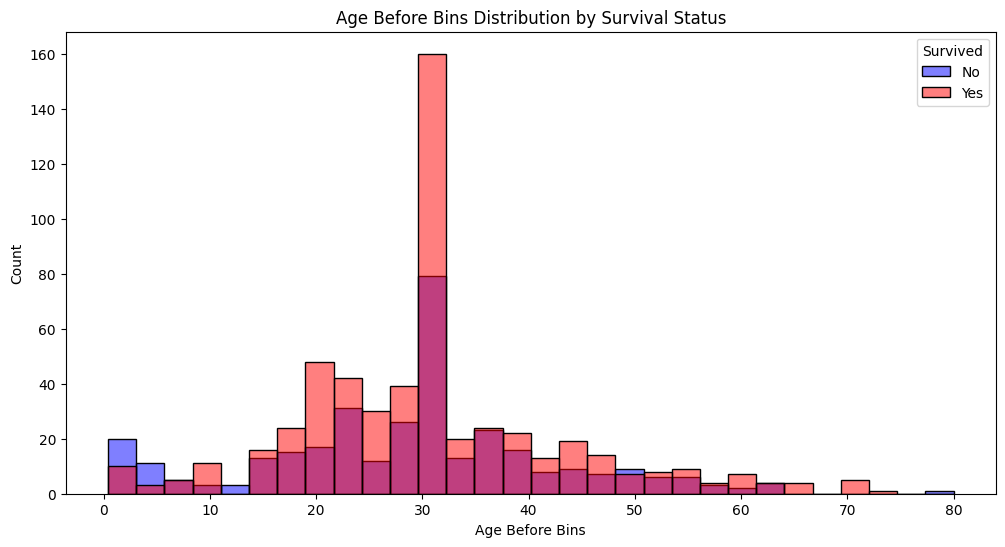

In [85]:

# Visualize Age distribution before binning
plt.figure(figsize=(12, 6))
sns.histplot(data=combined_data.loc[: len(train_data) - 1], x='Age', hue=train_survived, kde=False, bins=30, palette=['red', 'blue'])
plt.title("Age Before Bins Distribution by Survival Status")
plt.xlabel("Age Before Bins")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

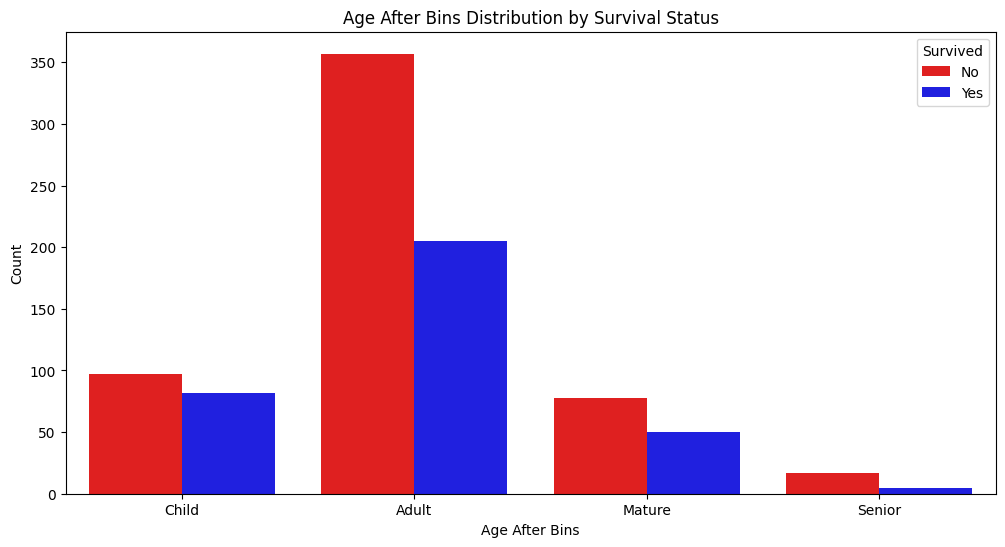

In [86]:
# Visualize Age distribution after binning
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_data.loc[: len(train_data) - 1], x='AgeBin', hue=train_survived, palette=['red', 'blue'])
plt.title("Age After Bins Distribution by Survival Status")
plt.xlabel("Age After Bins")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

In [87]:
# Encode 'AgeBin'
combined_data = ordinalencoder(combined_data, labels=['AgeBin'], drop_col=True)

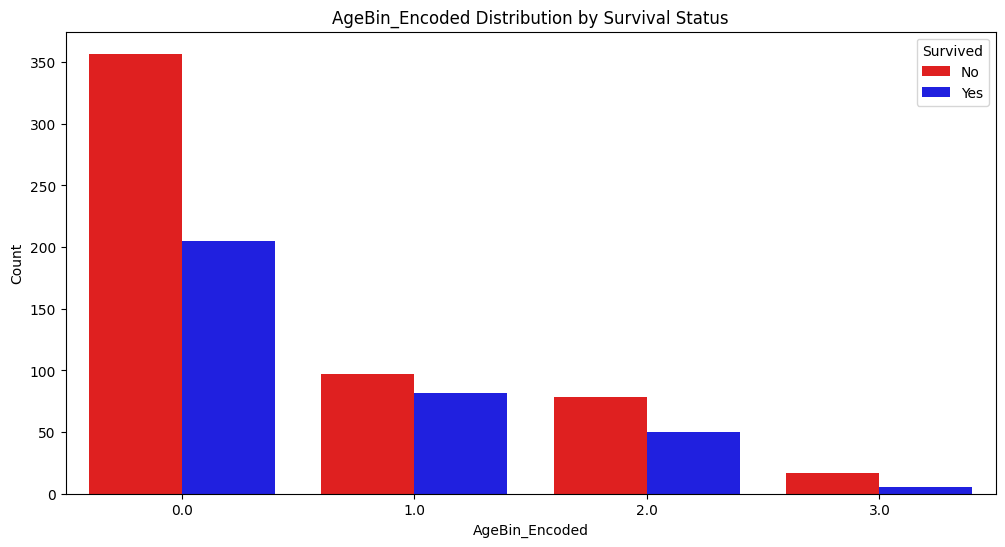

In [88]:
# Visualize the encoded 'AgeBin'
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_data.loc[: len(train_data) - 1], x='AgeBin_Encoded', hue=train_survived, palette=['red', 'blue'])
plt.title("AgeBin_Encoded Distribution by Survival Status")
plt.xlabel("AgeBin_Encoded")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

Through the correlation heatmap, we identified patterns and relationships between features, indicating potential interactions that could influence survival outcomes. To capture these relationships explicitly, we created interaction terms, which combine two or more variables to represent their joint effect.

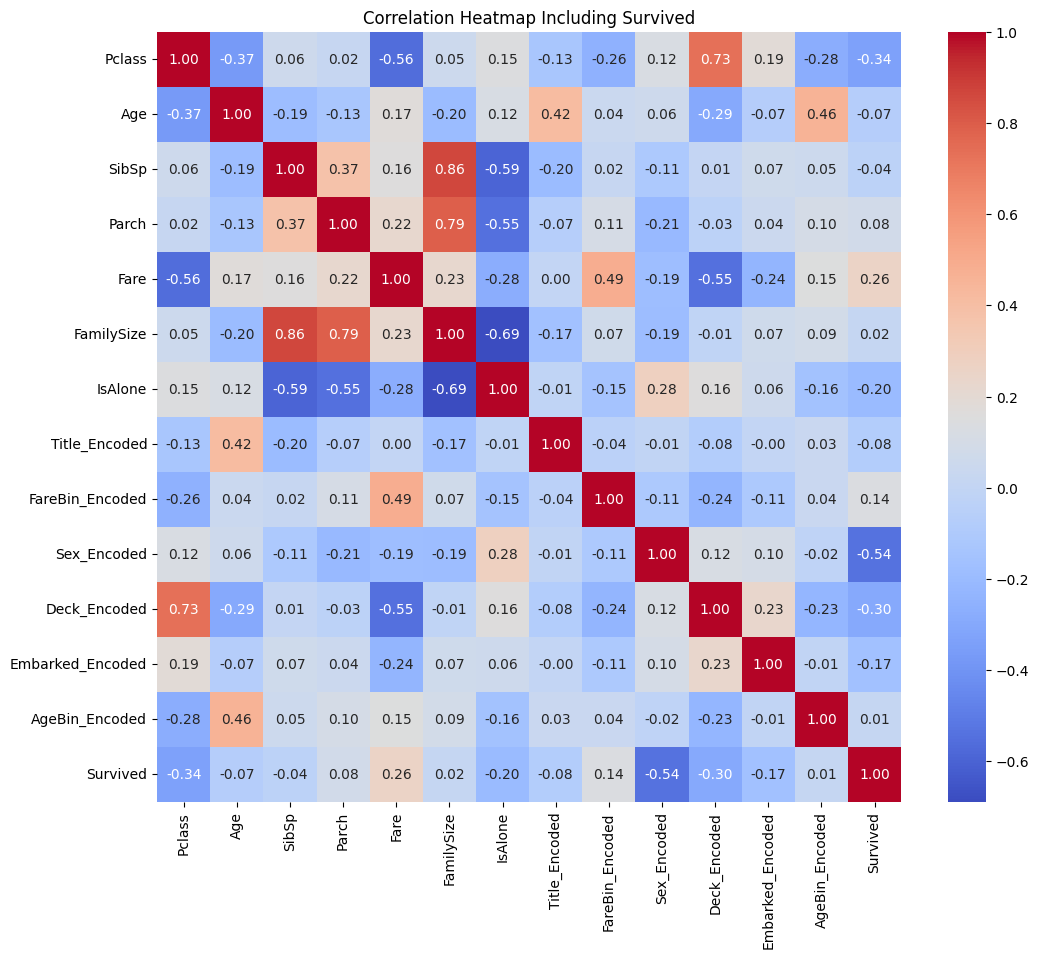

In [89]:
# Add the 'Survived' column back to the training data rows
combined_data.loc[:len(train_data) - 1, 'Survived'] = train_survived

# Drop PassengerId to focus on relevant features
corr_data = combined_data.drop(columns=['PassengerId'], errors='ignore')

# Compute the correlation matrix
corr_matrix = corr_data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Including Survived')
plt.show()

For example, we combined Age and Pclass into an interaction term (Age_Pclass) to represent how age and passenger class together influenced survival. These terms, informed by both correlation coefficients and domain knowledge, aimed to enhance the model’s ability to capture nuanced patterns in the data.

The heatmap revealed a significant correlation between Age and Pclass, prompting the creation of an interaction term. By multiplying these variables, we generated a new feature (Age_Pclass) that encapsulates their combined influence on survival outcomes.

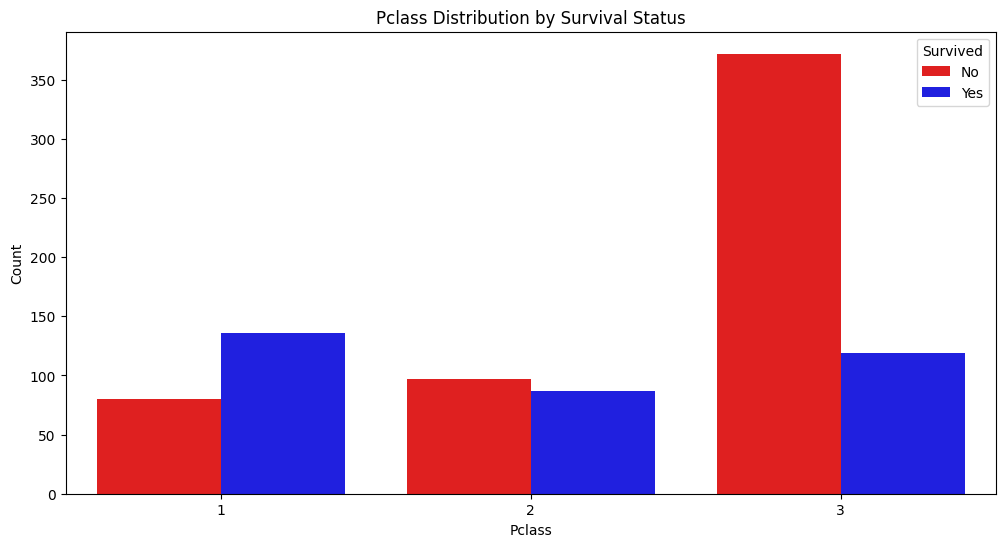

In [90]:

# Visualize Pclass distribution by Survival Status
plt.figure(figsize=(12, 6))
sns.countplot(
    data=combined_data.loc[: len(train_data) - 1],  # Only rows corresponding to train_data
    x='Pclass',
    hue=train_survived,
    palette=['red', 'blue']
)
plt.title("Pclass Distribution by Survival Status")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.legend(title="Survived", loc='upper right', labels=["No", "Yes"])
plt.show()

In [91]:
# Create interaction term Age_Pclass
combined_data['Age_Pclass'] = combined_data['Age'] * combined_data['Pclass']

In [92]:
combined_data.columns

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'IsAlone', 'Title_Encoded', 'FareBin_Encoded', 'Sex_Encoded',
       'Deck_Encoded', 'Embarked_Encoded', 'AgeBin_Encoded', 'Survived',
       'Age_Pclass'],
      dtype='object')

**Splitting Data and Model Training**

The split_data function divides the dataset into 88% training and 12% validation sets, ensuring the target variable is separated from the features. The random_state parameter ensures reproducibility.

After experimenting with various split ratios, 12% provided the best balance between sufficient training data and reliable validation results, optimizing model performance.

A logistic regression model was defined within a pipeline that includes feature scaling using StandardScaler.
A parameter grid was created to optimize hyperparameters such as regularization strength (C) and solver (liblinear and lbfgs). 
These configurations were set up for GridSearchCV, which performs cross-validation to find the best hyperparameters.

Using GridSearchCV, the logistic regression model was trained and validated. The best parameters were identified, and the model's performance was evaluated on the validation set. 
Metrics such as accuracy, log loss, and confusion matrix were computed to assess how well the model predicts survival.




Training LogisticRegression...
Best Parameters for LogisticRegression: {'logisticregression__C': 0.1, 'logisticregression__solver': 'lbfgs'}


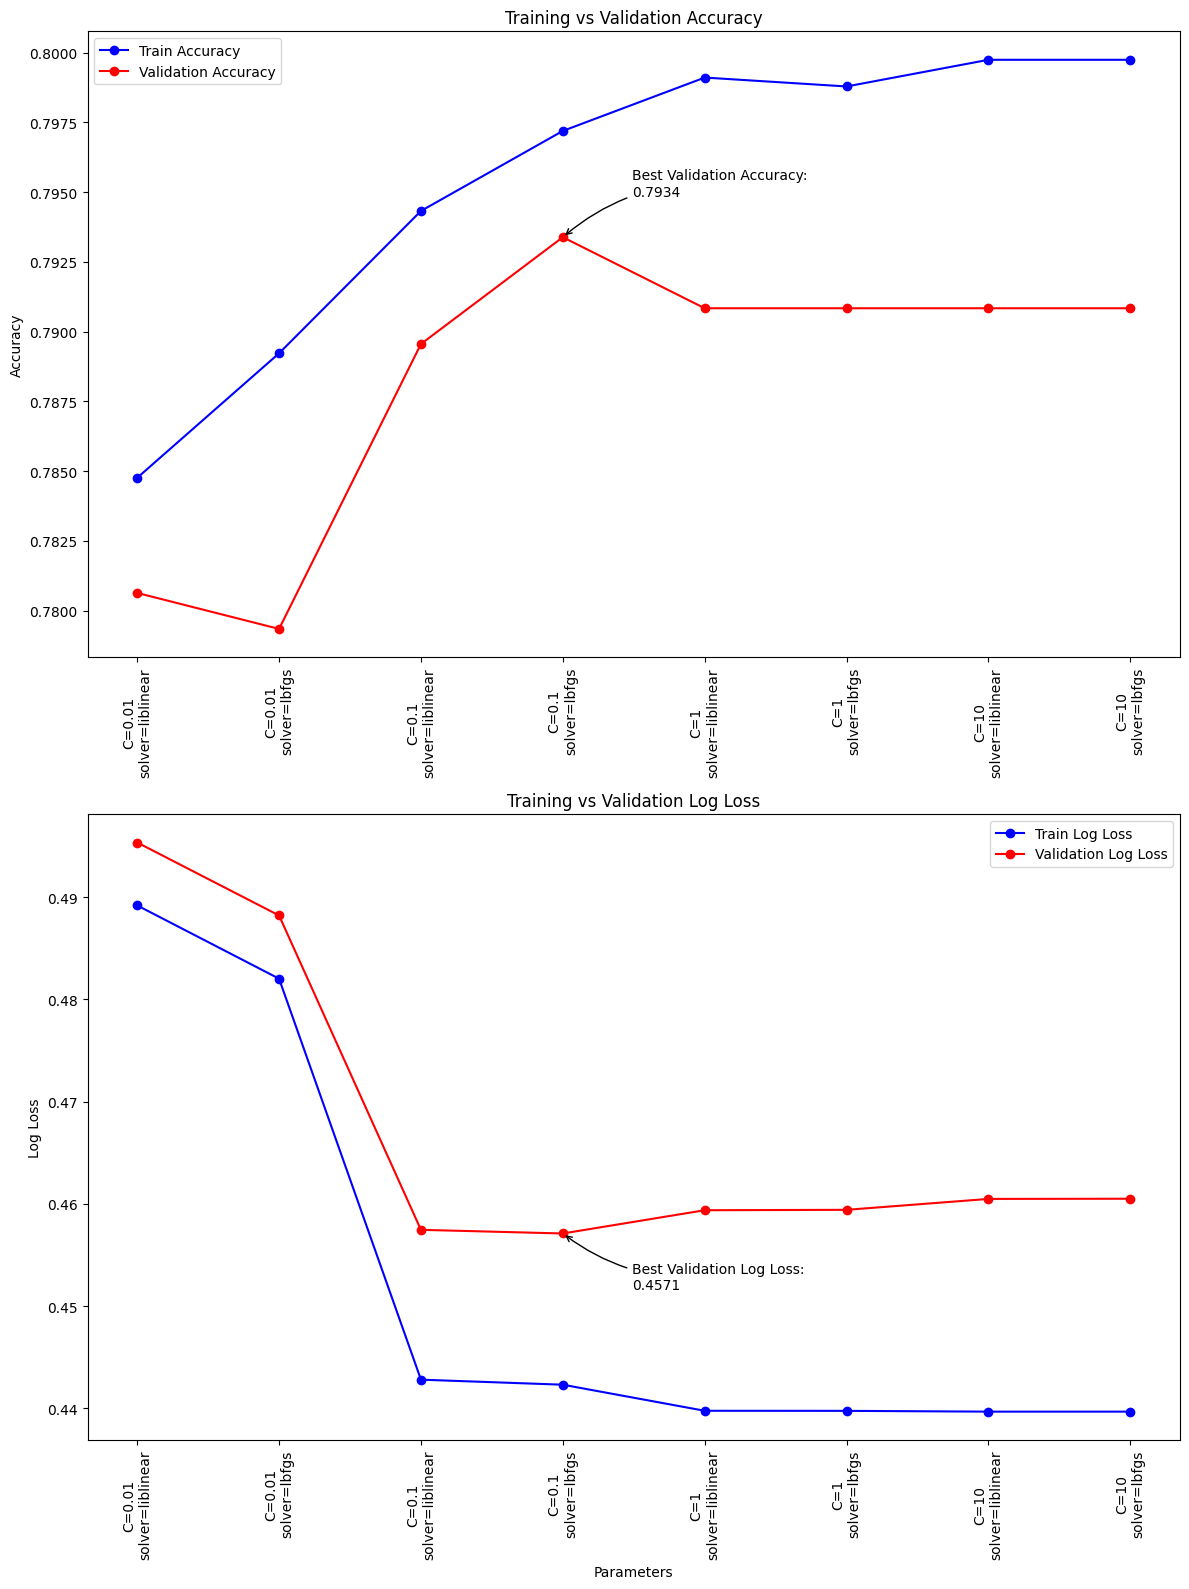


Model Performance Summary:


,Precision,Recall,Specificity,FPR,Accuracy,Balanced Accuracy,F1 Score,Model
0,0.825,0.785714,0.892308,0.107692,0.850467,0.839011,0.804878,LogisticRegression


In [93]:
# Separate back into training and test sets
titanic_full_train = combined_data.loc[: len(train_data) - 1].copy()
titanic_full_train['Survived'] = train_survived  # Add 'Survived' back for training
titanic_full_test = combined_data.loc[len(train_data):].copy()
# Drop 'Survived' from the test dataset if it exists
titanic_full_test = titanic_full_test.drop(columns=["Survived"], errors="ignore")


# Split the data
x_train, x_val, t_train, t_val = split_data(titanic_full_train, 'Survived')

# --- Define Models ---
# Define pipelines and parameter grids for GridSearchCV
models = {
    'LogisticRegression': {
        'pipeline': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        'params': {
            'logisticregression__C': [0.01, 0.1, 1, 10],
            'logisticregression__solver': ['liblinear', 'lbfgs']
        }
    }
}

# Scoring metrics for GridSearchCV
scoring = {
    'accuracy': 'accuracy',
    'neg_log_loss': make_scorer(log_loss, greater_is_better=False, response_method="predict_proba")
}

# Initialize results DataFrame
model_kpi_df = pd.DataFrame()
fitted_models = {}
    
# Adjust display options for better DataFrame visualization
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows',100)
pd.set_option('display.max_columns', None)

# --- Model Training ---
for name, info in models.items():
    print(f"\nTraining {name}...")
    grid_search = GridSearchCV(
        estimator=info['pipeline'],
        param_grid=info['params'],
        scoring=scoring,
        cv=5,
        refit='accuracy',
        return_train_score=True
    )
    grid_search.fit(x_train, t_train.values.ravel())
    
    # Save the best estimator
    fitted_models[name] = grid_search.best_estimator_
    print(f"Best Parameters for {name}: {grid_search.best_params_}")
    
    # Plot results
    plot_results(grid_search)
    
    # Evaluate on validation data
    y_pred = fitted_models[name].predict(x_val)
    kpi_df, confusion_mtx = model_kpi(t_val, y_pred)
    kpi_df['Model'] = name
    model_kpi_df = pd.concat([model_kpi_df, kpi_df], ignore_index=True)

# Sort KPIs by accuracy
model_kpi_df = model_kpi_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display KPI summary
print("\nModel Performance Summary:")
display(model_kpi_df)

The charts illustrate the performance of the logistic regression model across different hyperparameter configurations during training and validation.


The model achieves the best validation accuracy of 79.34% when using C=0.1 and the solver liblinear.

Log Loss, which evaluates the model's probabilistic predictions, reaches its lowest validation value of 0.4571 at the same configuration.

The slight gap between training and validation performance suggests the model generalizes well without overfitting.


This table summarizes the key performance metrics for the logistic regression model on the validation dataset.


- Precision: 82.5%, indicating the proportion of correctly predicted survivors among those predicted as survivors.

- Recall: 78.57%, reflecting the model's ability to correctly identify actual survivors.

- F1 Score: 80.48%, balancing precision and recall.

- Accuracy: 85.05%, showing the overall proportion of correct predictions.



Logistic Regression Evaluation:
Train: TN 419, FP 65, FN 92, TP 208
Validation: TN 58, FP 7, FN 9, TP 33


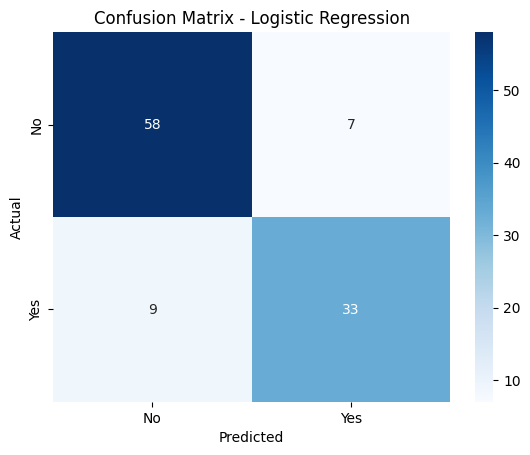

In [94]:
#%%

# Logistic Regression Evaluation
best_log_reg = fitted_models['LogisticRegression']
print("\nLogistic Regression Evaluation:")

# Train Confusion Matrix
y_pred_train_log_reg = best_log_reg.predict(x_train)
conf_matrix_train_log_reg = confusion_matrix(t_train, y_pred_train_log_reg)
display_confusion_metrics(conf_matrix_train_log_reg, "Train")

# Validation Confusion Matrix
y_pred_val_log_reg = best_log_reg.predict(x_val)
conf_matrix_val_log_reg = confusion_matrix(t_val, y_pred_val_log_reg)
display_confusion_metrics(conf_matrix_val_log_reg, "Validation")

# Visualization of Validation Confusion Matrix
sns.heatmap(conf_matrix_val_log_reg, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix offers a detailed breakdown of the model's predictions on the validation dataset.

- True Negatives (TN): 58 passengers correctly predicted as non-survivors.

- False Positives (FP): 7 passengers incorrectly predicted as survivors.

- False Negatives (FN): 9 passengers incorrectly predicted as non-survivors.

- True Positives (TP): 33 passengers correctly predicted as survivors.

The confusion matrix highlights areas for potential improvement, such as reducing the false negative rate to enhance the recall score.

In [95]:
# --- Perform Prediction for Kaggle ---
best_model_name = model_kpi_df.loc[0, "Model"]  # Get the best model's name
best_model = fitted_models[best_model_name]     # Retrieve the best model

# Perform prediction on test data
X_test = titanic_full_test.copy()

# Ensure test features align with training features
X_test = X_test[x_train.columns]

# Predict with the best model
test_predictions = best_model.predict(X_test)

# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': test_ids,  # Ensure PassengerId matches the test dataset
    'Survived': test_predictions.astype(int)  # Ensure predictions are integers
})

# Save the submission file
submission.to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' created successfully!")

Submission file 'submission.csv' created successfully!


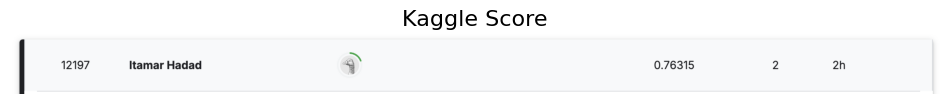

In [96]:
image_path = '/Users/itamarhadad/Desktop/study/MachineLearning/newtask2/Kaggle screenshot.png' 

img = mpimg.imread(image_path)

plt.figure(figsize=(12, 6))  
plt.imshow(img)
plt.axis('off') 
plt.title('Kaggle Score', fontsize=16) 
plt.show()


The score 0.76315 represents the result achieved on the Kaggle platform for the Titanic dataset.

**Sorces**

1. https://www.encyclopedia-titanica.org/titanic-deckplans/ (Titanic Layout)

2. https://www.kaggle.com/code/ferasalshash/titanic-data-analysis-and-predictive-modeling (Kaggle Note book)

3. https://towardsdatascience.com/titanic-feature-engineering-modeling-in-python-6749e6e87bf4 (Feature Engineering & Modeling in Python)

